# 07 — Abundance Calculations from G395M Spectrum

**Purpose:** Test the `jwspecabund` package on a real G395M grating spectrum
with a strong [OIII] 4363 detection. Compares three methods:
1. **Direct T_e** — classical auroral-line temperature diagnostic
2. **Forward model** — Bayesian forward modelling (Cullen+25 approach)
3. **Strong-line** — Sanders+25 polynomial calibrations

Uses `jwspecmcmc` for MCMC posterior sampling, propagating full posteriors
through abundance calculations instead of symmetric bootstrap errors.

**Data:** `excels-uds04-v4_g395m-f290lp_3543_63107.spec.fits` — a galaxy at z = 8.271.

**Date:** 2026-02-20

In [1]:
import jwspecfit
import jwspecmcmc
import jwspecabund
import matplotlib.pyplot as plt
import numpy as np

print(f"jwspecfit   v{jwspecfit.__version__}")
print(f"jwspecmcmc  v{jwspecmcmc.__version__}")
print(f"jwspecabund v{jwspecabund.__version__}")

jwspecfit   v1.0.0
jwspecmcmc  v1.0.0
jwspecabund v1.0.0


## 1. Load the G395M spectrum

In [2]:
spec = jwspecfit.read_fits(
    "../../data/excels-uds04-v4_g395m-f290lp_3543_63107.spec.fits",
    z=8.271,
)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} \u2013 {spec.wave_um.max():.3f} \u00b5m")

Grating:    G395M
Pixels:     1661
Wave range: 2.680 – 5.510 µm


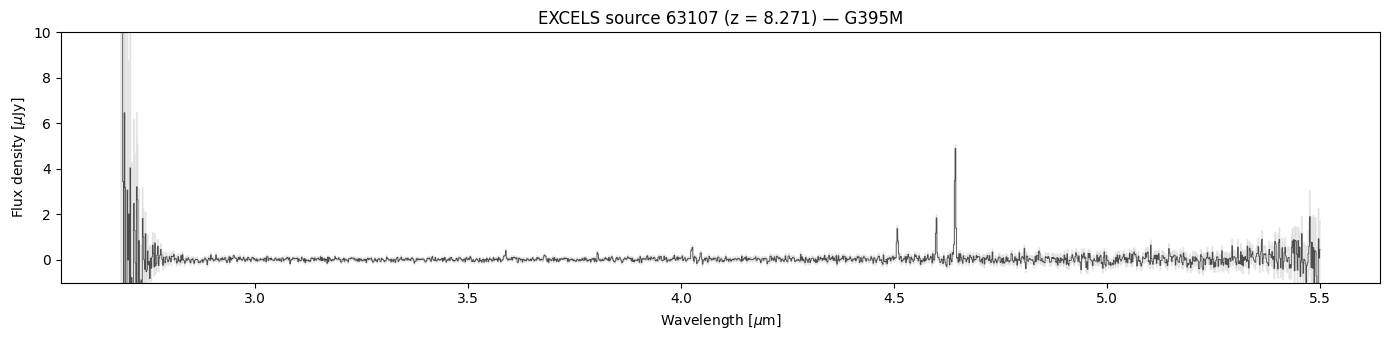

In [3]:
fig, ax = plt.subplots(figsize=(14, 3.5))
valid = spec.mask_valid()
ax.step(spec.wave_um[valid], spec.flux_ujy[valid], where="mid", lw=0.6, color="0.3")
ax.fill_between(
    spec.wave_um[valid],
    (spec.flux_ujy - spec.err_ujy)[valid],
    (spec.flux_ujy + spec.err_ujy)[valid],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"Flux density [$\mu$Jy]")
ax.set_ylim(-1, 10)
ax.set_title("EXCELS source 63107 (z = 8.271) — G395M")
plt.tight_layout()

## 2. Fit emission lines

Run an MCMC fit with BIC-based broad Balmer component search.
This spectrum has strong [OIII] 4363 — the key auroral line for the
direct T_e method.

In [4]:
mcmc_result = jwspecmcmc.fit_lines(spec, z=8.271, deg=3, sampler="emcee", n_steps=3000)
result = mcmc_result.to_fit_result()  # FitResult for plotting / chi2

Resolving power: R = 1000
Resolving power: R = 1000
Resolving power: R = 1000


100%|██████████| 3000/3000 [02:53<00:00, 17.27it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 55 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [301.59289949 273.55449071 270.04967916 280.14670516 251.13619678
 316.34067961 249.65465539 239.3436257  218.10738532 266.21789636
 296.13614531 336.48659274 301.45423233 294.42724413 258.9426096
 296.38458955 275.95187767 289.52045586 196.48648228 150.07704223
  95.56549073 319.33705161 261.94270051 318.53188145 334.50859335
 322.21918302 313.44392634 328.38528125 330.96872035 333.79025198
 295.66028134 338.59740783 306.45262737 325.55907607 337.23445603
 276.38873736 283.56657318 329.91755314 293.89040884 343.76362629
 342.10855526 348.71386205 329.86357268 326.35209174 328.09148003
 324.55552407 305.57488139 327.92371883 337.45291017 323.28330127
 345.69535088 331.70280694 310.04775643 335.13624329 317.38381678]


In [5]:
print(f"Selected model: {mcmc_result.selected_model}")
print(f"Lines fitted:   {len(mcmc_result.lines)}")
print(f"chi2/dof:       {result.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err(-)':>12s} {'Err(+)':>12s} {'SNR':>8s} {'EW (A)':>10s}")
print("-" * 77)
for name, lr in mcmc_result.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(
        f"{name + tag:<18s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e}"
        f" {lr.flux_err[1]:12.3e} {lr.snr:8.1f} {lr.ew_A:10.1f}"
    )

Selected model: narrow
Lines fitted:   23
chi2/dof:       0.87

Line                       Flux       Err(-)       Err(+)      SNR     EW (A)
-----------------------------------------------------------------------------
OII_3726              4.971e-20    3.852e-20    6.205e-20      1.0       12.2
OII_3729              8.828e-20    5.872e-20    5.965e-20      1.5       21.7
H10                   4.784e-20    3.374e-20    4.835e-20      1.2       11.9
H9                    4.369e-20    3.170e-20    4.982e-20      1.1       10.9
NeIII_3869            4.021e-19    9.544e-20    7.724e-20      4.7      100.5
H8                    1.015e-19    5.971e-20    5.465e-20      1.8       25.4
HEPSILON              1.622e-19    4.550e-20    4.879e-20      3.4       40.4
HDELTA                2.107e-19    5.475e-20    5.836e-20      3.7       51.8
HGAMMA                4.167e-19    6.662e-20    7.025e-20      6.1       99.3
OIII_4363             2.252e-19    6.829e-20    6.305e-20      3.4       53.6


/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


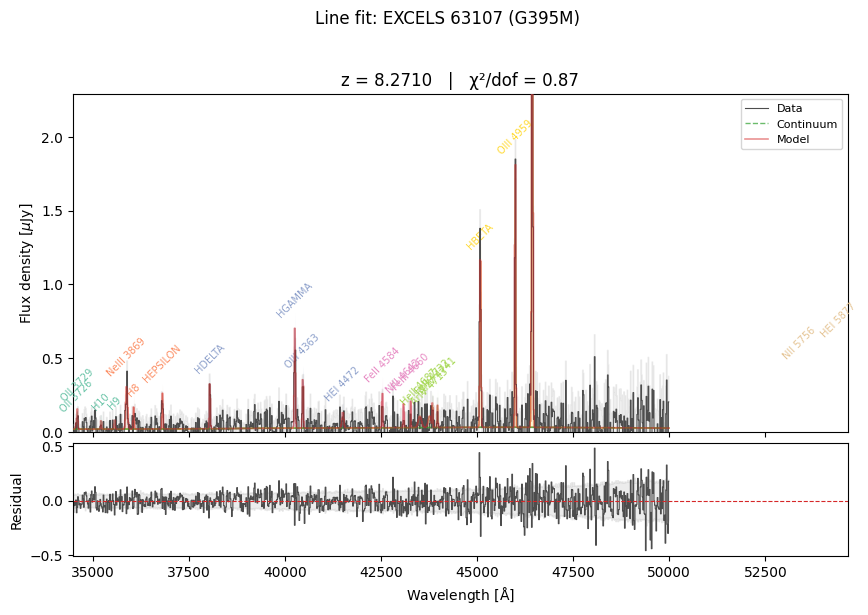

In [6]:
fig = jwspecfit.plot_fit(result, exclude_wave_A=[(20000, 28000), (50000, 60000)],flux_unit="fnu",y_pad=0.5)
fig.suptitle("Line fit: EXCELS 63107 (G395M)", y=1.02)
plt.show()

In [7]:
fig_interactive = jwspecfit.plot_fit_interactive(result)
fig_interactive.show()

## 3. Compute abundances — auto mode

The `compute_abundances` function automatically selects the direct T_e method
when [OIII] 4363 is detected above the SNR threshold (default 3). It also
derives A_V from the Balmer decrement before correcting all line fluxes.

In [8]:
abund_auto = jwspecabund.compute_abundances(mcmc_result, z=8.271, n_mc=1000)
print(abund_auto.summary())

PyNEB returned invalid n_e=nan; using 100 cm^-3.
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 0/1000 [00:00<?, ?it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.021 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 3/1000 [00:00<00:33, 29.95it/s]Z/Zsun=0.016 outside validity range [0.05, 0.40].
Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Direct Te (posterior):   1%|          | 6/1000 [00:00<00:34, 28.92it/s]Z/Zsun=0.020 outside validity range [0.05, 0.40].
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.010 outside validity range [0.05, 0.40].
Z/Zsun=0.008 outside validity range [0.05, 0.40].
Direct Te (posterior):   1%|▏         | 13/1000 [00:00<00:20, 47.13it/s]Z/Zsun=0.007 outside validity range [0.05, 0.40].
Z/Zsun=0.040 outside val

AbundanceResult (method=direct)
  12+log(O/H) = 6.795 +/- (0.19424403614990293, 0.20804523943443787)
  log(Ne/O)   = -1.013
  T_e(high)   = 52515 K
  T_e(low)    = 37300 K
  n_e         = 100 cm^-3
  n_e(low)    = 100 cm^-3
  n_e(high)   = 100 cm^-3
  log(U)      = -1.63
  A_V         = 0.000


## 4. Direct method in detail

Explicitly run the direct method and inspect all intermediate quantities
(T_e, n_e, ionic abundances, ICFs).

In [9]:
abund_direct = jwspecabund.compute_abundances(
    mcmc_result, z=8.271,
    method="direct",
    dust_law="salim",
    Te_relation="classical",
    n_mc=1000,
)

print(f"Method:        {abund_direct.method}")
print(f"A_V:           {abund_direct.Av:.3f}")
print(f"T_e(high):     {abund_direct.Te_high:.0f} K")
print(f"T_e(low):      {abund_direct.Te_low:.0f} K")
print(f"n_e:           {abund_direct.ne:.0f} cm^-3")
if isinstance(abund_direct.OH_err, tuple):
    print(f"12+log(O/H):   {abund_direct.OH:.3f} (-{abund_direct.OH_err[0]:.3f}, +{abund_direct.OH_err[1]:.3f})")
else:
    print(f"12+log(O/H):   {abund_direct.OH:.3f} +/- {abund_direct.OH_err:.3f}")
if abund_direct.NO is not None:
    if isinstance(abund_direct.NO_err, tuple):
        print(f"log(N/O):      {abund_direct.NO:.3f} (-{abund_direct.NO_err[0]:.3f}, +{abund_direct.NO_err[1]:.3f})")
    else:
        print(f"log(N/O):      {abund_direct.NO:.3f} +/- {abund_direct.NO_err}")

PyNEB returned invalid n_e=nan; using 100 cm^-3.


Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 0/1000 [00:00<?, ?it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.021 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 4/1000 [00:00<00:32, 30.40it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Z/Zsun=0.020 outside validity range [0.05, 0.40].
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   1%|          | 8/1000 [00:00<00:30, 32.14it/s]Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.010 outside validity range [0.05, 0.40].
Z/Zsun=0.008 outside validity range [0.05, 0.40].
Z/Zsun=0.007 outside validity range [0.05, 0.40].
Z/Zsun=0.039 outside validity range [0.05, 0.40].
Direct Te (posterior):   2%|▏         | 16/1000 [00:00<00:22, 43.84it/s]Z/Zsun=0.022 outside va

Method:        direct
A_V:           0.000
T_e(high):     52515 K
T_e(low):      39761 K
n_e:           100 cm^-3
12+log(O/H):   6.794 (-0.194, +0.206)


In [10]:
# Ionic abundances
if abund_direct.ionic:
    print("Ionic abundances:")
    for ion, val in abund_direct.ionic.items():
        print(f"  {ion:<12s} = {val:.3e}  (12+log = {12 + np.log10(val):.3f})")

Ionic abundances:
  O++/H+       = 5.368e-06  (12+log = 6.730)
  O+/H+        = 1.993e-07  (12+log = 5.299)
  Ne++/H+      = 1.488e-06  (12+log = 6.173)


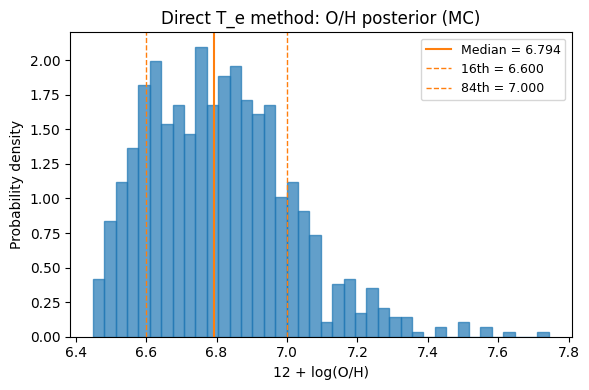

In [11]:
# MC posterior on 12+log(O/H)
if abund_direct.OH_posterior is not None:
    oh_post = abund_direct.OH_posterior
    oh_post = oh_post[np.isfinite(oh_post)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(oh_post, bins=40, density=True, alpha=0.7, color="C0", edgecolor="C0")
    med = np.nanmedian(oh_post)
    lo = np.nanpercentile(oh_post, 16)
    hi = np.nanpercentile(oh_post, 84)
    ax.axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.3f}")
    ax.axvline(lo, color="C1", ls="--", lw=1, label=f"16th = {lo:.3f}")
    ax.axvline(hi, color="C1", ls="--", lw=1, label=f"84th = {hi:.3f}")
    ax.set_xlabel("12 + log(O/H)")
    ax.set_ylabel("Probability density")
    ax.set_title("Direct T_e method: O/H posterior (MC)")
    ax.legend(fontsize=9)
    plt.tight_layout()

## 5. Strong-line method (Sanders+25)

For comparison, compute the metallicity using only the strong-line
calibrations — as would be done if [OIII] 4363 were undetected.

In [12]:
abund_strong = jwspecabund.compute_abundances(
    mcmc_result, z=8.271,
    method="strong_line",
    dust_law="salim",
    n_mc=1000,
)

print(f"Method:        {abund_strong.method}")
print(f"A_V:           {abund_strong.Av:.3f}")
print(f"12+log(O/H):   {abund_strong.OH:.3f} (-{abund_strong.OH_err[0]:.3f}, +{abund_strong.OH_err[1]:.3f})")
print(f"Ratios used:   {abund_strong.ratios_used}")
#print(f"chi2:          {abund_strong.chi2:.2f}")

Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 9630.68it/s]


Method:        strong_line
A_V:           0.000
12+log(O/H):   7.105 (-0.073, +0.095)
Ratios used:   ['O3', 'O2', 'R23', 'O32']


## 6. Compare direct vs strong-line

Side-by-side comparison of the two methods.

In [13]:
print(f"{'':>20s} {'Direct T_e':>18s} {'Strong-line':>18s}")
print("-" * 58)

# Format O/H errors
if isinstance(abund_direct.OH_err, tuple):
    d_err = f"(-{abund_direct.OH_err[0]:.3f}, +{abund_direct.OH_err[1]:.3f})"
else:
    d_err = f"+/- {abund_direct.OH_err:.3f}"

if isinstance(abund_strong.OH_err, tuple):
    s_err = f"(-{abund_strong.OH_err[0]:.3f}, +{abund_strong.OH_err[1]:.3f})"
else:
    s_err = f"+/- {abund_strong.OH_err:.3f}"

print(f"{'12+log(O/H)':>20s} {abund_direct.OH:>8.3f} {d_err:>9s} {abund_strong.OH:>8.3f} {s_err:>9s}")

if abund_direct.NO is not None:
    print(f"{'log(N/O)':>20s} {abund_direct.NO:>18.3f} {'---':>18s}")

if abund_direct.Te_high is not None:
    print(f"{'T_e(high) [K]':>20s} {abund_direct.Te_high:>18.0f} {'---':>18s}")
    print(f"{'T_e(low) [K]':>20s} {abund_direct.Te_low:>18.0f} {'---':>18s}")

print(f"{'A_V':>20s} {abund_direct.Av:>18.3f} {abund_strong.Av:>18.3f}")

                             Direct T_e        Strong-line
----------------------------------------------------------
         12+log(O/H)    6.794 (-0.194, +0.206)    7.105 (-0.073, +0.095)
       T_e(high) [K]              52515                ---
        T_e(low) [K]              39761                ---
                 A_V              0.000              0.000


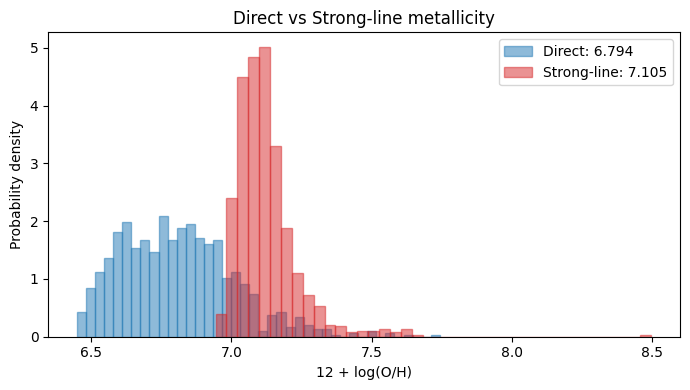

In [14]:
# Overlay O/H posteriors from both methods
fig, ax = plt.subplots(figsize=(7, 4))

if abund_direct.OH_posterior is not None:
    oh_d = abund_direct.OH_posterior[np.isfinite(abund_direct.OH_posterior)]
    ax.hist(oh_d, bins=40, density=True, alpha=0.5, color="C0",
            edgecolor="C0", label=f"Direct: {np.nanmedian(oh_d):.3f}")

if abund_strong.OH_posterior is not None:
    oh_s = abund_strong.OH_posterior[np.isfinite(abund_strong.OH_posterior)]
    ax.hist(oh_s, bins=40, density=True, alpha=0.5, color="C3",
            edgecolor="C3", label=f"Strong-line: {np.nanmedian(oh_s):.3f}")

ax.set_xlabel("12 + log(O/H)")
ax.set_ylabel("Probability density")
ax.set_title("Direct vs Strong-line metallicity")
ax.legend(fontsize=10)
plt.tight_layout()

## 7. Forward Model (Cullen+25 approach)

The **forward model** treats ionic abundances, electron temperature, and
electron density as free parameters sampled via MCMC.  For each parameter
vector it predicts line/Hβ flux ratios using PyNEB emissivities (for CELs)
and the Aller (1984) Hβ recombination formula (valid at any temperature),
then compares to observed ratios via a Gaussian likelihood.

This matches the method of Cullen et al. (2025) and avoids the two-step
"compute Te then abundances" approach of the classical direct method.

In [15]:
# Run the forward model via compute_abundances(method="forward")
# Uses the dust-corrected fluxes with emcee MCMC sampling.
abund_forward = jwspecabund.compute_abundances(
    mcmc_result, z=8.271,
    method="forward",
    dust_law="salim",
    forward_sampler="emcee",
    forward_n_walkers=32,
    forward_n_steps=5000,
    forward_n_burn=1000,
    forward_seed=42,
    forward_progress=True,
)

print(abund_forward.summary())
print()

# Access the full forward model result for detailed posteriors
fwd = abund_forward._forward_result
print(f"Free parameters: {fwd['param_names']}")
print(f"Posterior samples shape: {fwd['samples'].shape}")
print(f"\nT_e = {fwd['Te']:.0f} K  (-{fwd['Te_err'][0]:.0f}, +{fwd['Te_err'][1]:.0f})")
print(f"n_e = {fwd['ne']:.0f} cm^-3  (-{fwd['ne_err'][0]:.0f}, +{fwd['ne_err'][1]:.0f})")

for pname, pmed in fwd['ionic'].items():
    print(f"{pname} = {pmed:.3f}")

100%|██████████| 5000/5000 [02:11<00:00, 37.90it/s]

AbundanceResult (method=forward)
  12+log(O/H) = 6.831 +/- (0.18874329999701, 0.24605130376545148)
  log(Ne/O)   = -0.559
  T_e(high)   = 42795 K
  n_e         = 325 cm^-3
  A_V         = 0.000

Free parameters: ['log_Te', 'log_ne', 'log_Opp', 'log_Op', 'log_Nepp']
Posterior samples shape: (128000, 5)

T_e = 42795 K  (-14947, +23225)
n_e = 325 cm^-3  (-319, +22005)
log_Opp = -5.189
log_Op = -6.680
log_Nepp = -5.754


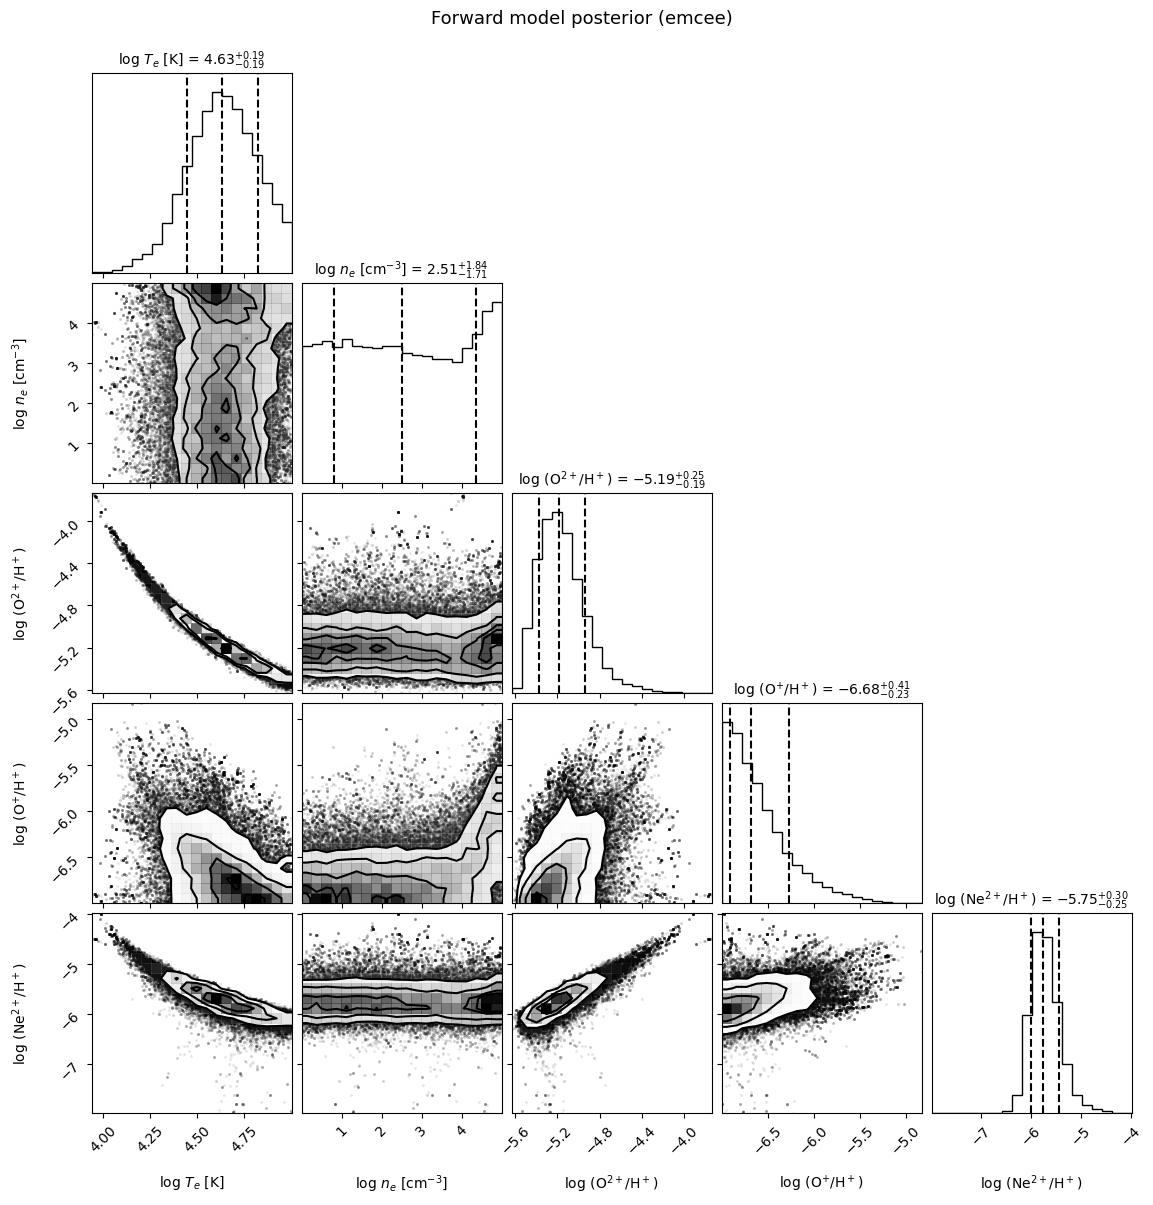

In [16]:
# Corner plot of the forward model posteriors
try:
    import corner

    labels = fwd["param_labels"]
    fig = corner.corner(
        fwd["samples"],
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 10},
    )
    fig.suptitle("Forward model posterior (emcee)", y=1.02, fontsize=13)
    plt.show()
except ImportError:
    print("Install `corner` for corner plots: pip install corner")

Method                12+log(O/H)        T_e [K]     n_e [cm-3]
--------------------------------------------------------------
Direct T_e                  6.794          52515            100
Forward model               6.831          42795            325
Strong-line                 7.105            ---            ---


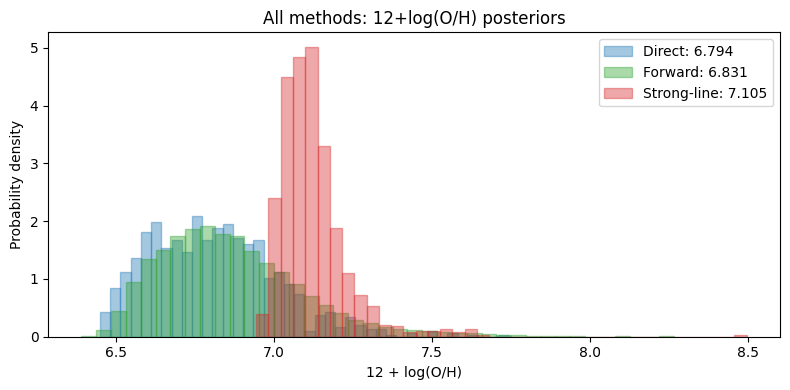

In [17]:
# Compare all three methods
print(f"{'Method':<18s} {'12+log(O/H)':>14s} {'T_e [K]':>14s} {'n_e [cm-3]':>14s}")
print("-" * 62)
print(f"{'Direct T_e':18s} {abund_direct.OH:14.3f} {abund_direct.Te_high:14.0f} {abund_direct.ne:14.0f}")
print(f"{'Forward model':18s} {abund_forward.OH:14.3f} {abund_forward.Te_high:14.0f} {abund_forward.ne:14.0f}")
print(f"{'Strong-line':18s} {abund_strong.OH:14.3f} {'---':>14s} {'---':>14s}")

# Overlay all O/H posteriors
fig, ax = plt.subplots(figsize=(8, 4))

if abund_direct.OH_posterior is not None:
    oh_d = np.array(abund_direct.OH_posterior)
    oh_d = oh_d[np.isfinite(oh_d)]
    ax.hist(oh_d, bins=40, density=True, alpha=0.4, color="C0",
            edgecolor="C0", label=f"Direct: {np.median(oh_d):.3f}")

if abund_forward.OH_posterior is not None:
    oh_f = np.array(abund_forward.OH_posterior)
    oh_f = oh_f[np.isfinite(oh_f)]
    ax.hist(oh_f, bins=40, density=True, alpha=0.4, color="C2",
            edgecolor="C2", label=f"Forward: {np.median(oh_f):.3f}")

if abund_strong.OH_posterior is not None:
    oh_s = np.array(abund_strong.OH_posterior)
    oh_s = oh_s[np.isfinite(oh_s)]
    ax.hist(oh_s, bins=40, density=True, alpha=0.4, color="C3",
            edgecolor="C3", label=f"Strong-line: {np.median(oh_s):.3f}")

ax.set_xlabel("12 + log(O/H)")
ax.set_ylabel("Probability density")
ax.set_title("All methods: 12+log(O/H) posteriors")
ax.legend(fontsize=10)
plt.tight_layout()

## 7. Dust correction comparison

Compare Salim+18 and Cardelli+89 dust laws on the same data.

In [18]:
abund_cardelli = jwspecabund.compute_abundances(
    mcmc_result, z=8.271,
    method="direct",
    dust_law="cardelli",
    n_mc=500,
)

print(f"{'Dust law':>15s} {'A_V':>8s} {'12+log(O/H)':>14s} {'T_e(high)':>12s}")
print("-" * 52)
print(f"{'Salim+18':>15s} {abund_direct.Av:>8.3f} {abund_direct.OH:>14.3f} {abund_direct.Te_high:>12.0f}")
print(f"{'Cardelli+89':>15s} {abund_cardelli.Av:>8.3f} {abund_cardelli.OH:>14.3f} {abund_cardelli.Te_high:>12.0f}")

PyNEB returned invalid n_e=nan; using 100 cm^-3.
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 0/1000 [00:00<?, ?it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.021 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 4/1000 [00:00<00:31, 31.59it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Z/Zsun=0.020 outside validity range [0.05, 0.40].
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   1%|          | 8/1000 [00:00<00:30, 32.59it/s]Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.010 outside validity range [0.05, 0.40].
Z/Zsun=0.008 outside validity range [0.05, 0.40].
Z/Zsun=0.007 outside validity range [0.05, 0.40].
Z/Zsun=0.040 outside validity range [0.05, 0.40].
Direct Te (posterior):   2%|▏         | 16/100

       Dust law      A_V    12+log(O/H)    T_e(high)
----------------------------------------------------
       Salim+18    0.000          6.794        52515
    Cardelli+89    0.000          6.795        52515


## 8. Inspect dust correction curves

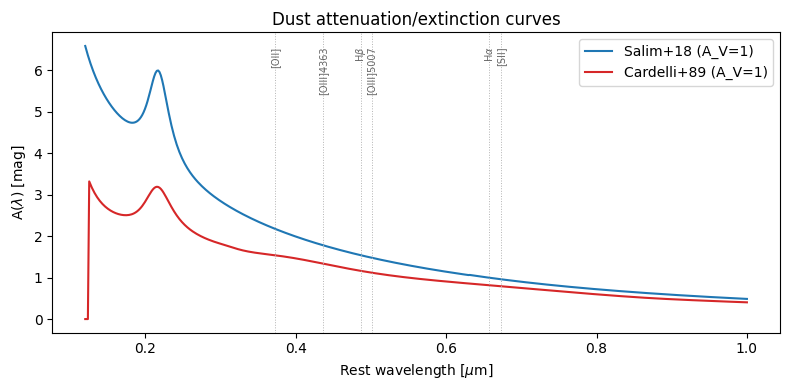

In [19]:
wave_grid = np.linspace(1200, 10000, 500)
Av_test = 1.0

A_salim = jwspecabund.salim_attenuation(wave_grid, Av_test)
A_cardelli = jwspecabund.cardelli_extinction(wave_grid, Av_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wave_grid / 1e4, A_salim, label="Salim+18 (A_V=1)", color="C0")
ax.plot(wave_grid / 1e4, A_cardelli, label="Cardelli+89 (A_V=1)", color="C3")

# Mark key emission lines
key_lines = {
    r"[OII]": 3728, r"H$\beta$": 4862, r"[OIII]4363": 4364,
    r"[OIII]5007": 5008, r"H$\alpha$": 6564, r"[SII]": 6727,
}
for label, wave in key_lines.items():
    ax.axvline(wave / 1e4, color="0.7", ls=":", lw=0.7)
    ax.text(wave / 1e4, ax.get_ylim()[1] * 0.95, label, fontsize=7,
            ha="center", va="top", rotation=90, color="0.4")

ax.set_xlabel(r"Rest wavelength [$\mu$m]")
ax.set_ylabel(r"A($\lambda$) [mag]")
ax.set_title("Dust attenuation/extinction curves")
ax.legend()
plt.tight_layout()

## 9. No dust correction

For reference, compute the uncorrected abundance to see the effect of dust.

In [20]:
abund_nodust = jwspecabund.compute_abundances(
    mcmc_result, z=8.271,
    method="direct",
    dust_correct=False,
    n_mc=500,
)

print(f"{'':>18s} {'With dust corr':>16s} {'No dust corr':>16s}")
print("-" * 52)
print(f"{'12+log(O/H)':>18s} {abund_direct.OH:>16.3f} {abund_nodust.OH:>16.3f}")
if abund_direct.Te_high is not None and abund_nodust.Te_high is not None:
    print(f"{'T_e(high) [K]':>18s} {abund_direct.Te_high:>16.0f} {abund_nodust.Te_high:>16.0f}")
if abund_direct.NO is not None and abund_nodust.NO is not None:
    print(f"{'log(N/O)':>18s} {abund_direct.NO:>16.3f} {abund_nodust.NO:>16.3f}")

PyNEB returned invalid n_e=nan; using 100 cm^-3.
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 0/1000 [00:00<?, ?it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.021 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Direct Te (posterior):   0%|          | 4/1000 [00:00<00:31, 31.51it/s]Z/Zsun=0.006 outside validity range [0.05, 0.40].
Z/Zsun=0.016 outside validity range [0.05, 0.40].
Z/Zsun=0.020 outside validity range [0.05, 0.40].
Z/Zsun=0.011 outside validity range [0.05, 0.40].
Direct Te (posterior):   1%|          | 8/1000 [00:00<00:31, 31.53it/s]Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.012 outside validity range [0.05, 0.40].
Z/Zsun=0.010 outside validity range [0.05, 0.40].
Z/Zsun=0.008 outside validity range [0.05, 0.40].
Z/Zsun=0.007 outside validity range [0.05, 0.40].
Z/Zsun=0.040 outside validity range [0.05, 0.40].
Direct Te (posterior):   2%|▏         | 16/100

                     With dust corr     No dust corr
----------------------------------------------------
       12+log(O/H)            6.794            6.795
     T_e(high) [K]            52515            52515


## 10. Key line ratios for cross-checking

Print the raw and dust-corrected line ratios that feed into the
abundance calculation. Compare these with published values.

In [21]:
lines = result.lines

def ratio_and_err(name_a, name_b):
    """Compute flux ratio and error from the fit result."""
    if name_a not in lines or name_b not in lines:
        return np.nan, np.nan
    fa = lines[name_a].flux
    fb = lines[name_b].flux
    ea = lines[name_a].flux_err
    eb = lines[name_b].flux_err
    if fb <= 0:
        return np.nan, np.nan
    r = fa / fb
    r_err = r * np.sqrt((ea / fa) ** 2 + (eb / fb) ** 2)
    return r, r_err

print("Observed (uncorrected) line ratios:")
print(f"{'Ratio':<30s} {'Value':>10s} {'Error':>10s}")
print("-" * 52)

ratio_list = [
    ("Ha / Hb",               "Ha",         "HBETA"),
    ("[OIII]5007 / Hb",       "OIII_5007",  "HBETA"),
    ("[OIII]4363 / [OIII]5007","OIII_4363", "OIII_5007"),
    ("[NII]6585 / Ha",        "NII_6585",   "Ha"),
    ("[SII]6718 / [SII]6732", "SII_6718",   "SII_6732"),
    ("HeI 5877 / Hb",         "HEI_5877",   "HBETA"),
]

for label, a, b in ratio_list:
    r, e = ratio_and_err(a, b)
    if np.isfinite(r):
        print(f"{label:<30s} {r:>10.4f} {e:>10.4f}")
    else:
        print(f"{label:<30s} {'---':>10s} {'---':>10s}")

Observed (uncorrected) line ratios:
Ratio                               Value      Error
----------------------------------------------------
Ha / Hb                               ---        ---
[OIII]5007 / Hb                    3.5233     0.4014
[OIII]4363 / [OIII]5007            0.0894     0.0263
[NII]6585 / Ha                        ---        ---
[SII]6718 / [SII]6732                 ---        ---
HeI 5877 / Hb                      0.9435     0.5952


## 11. Strong-line diagnostics breakdown

Show the individual diagnostic ratios and how they compare to the
Sanders+25 calibration curves.

In [22]:
from jwspecabund.strong_line import CALIBRATIONS, Z_REF, compute_line_ratios

# Extract fluxes from the fit result
fluxes = {name: lr.flux for name, lr in result.lines.items() if "BROAD" not in name}
errors = {name: lr.flux_err for name, lr in result.lines.items() if "BROAD" not in name}

ratios = compute_line_ratios(fluxes, errors)

print(f"Available diagnostics: {list(ratios.keys())}")
print()
for name, data in ratios.items():
    print(f"  {name}: log(R) = {data['val']:.3f} +/- {data['err']:.3f}")

Available diagnostics: ['O3', 'O2', 'R23', 'O32']

  O3: log(R) = 0.547 +/- 0.049
  O2: log(R) = -0.714 +/- 0.249
  R23: log(R) = 0.570 +/- 0.051
  O32: log(R) = 1.261 +/- 0.245


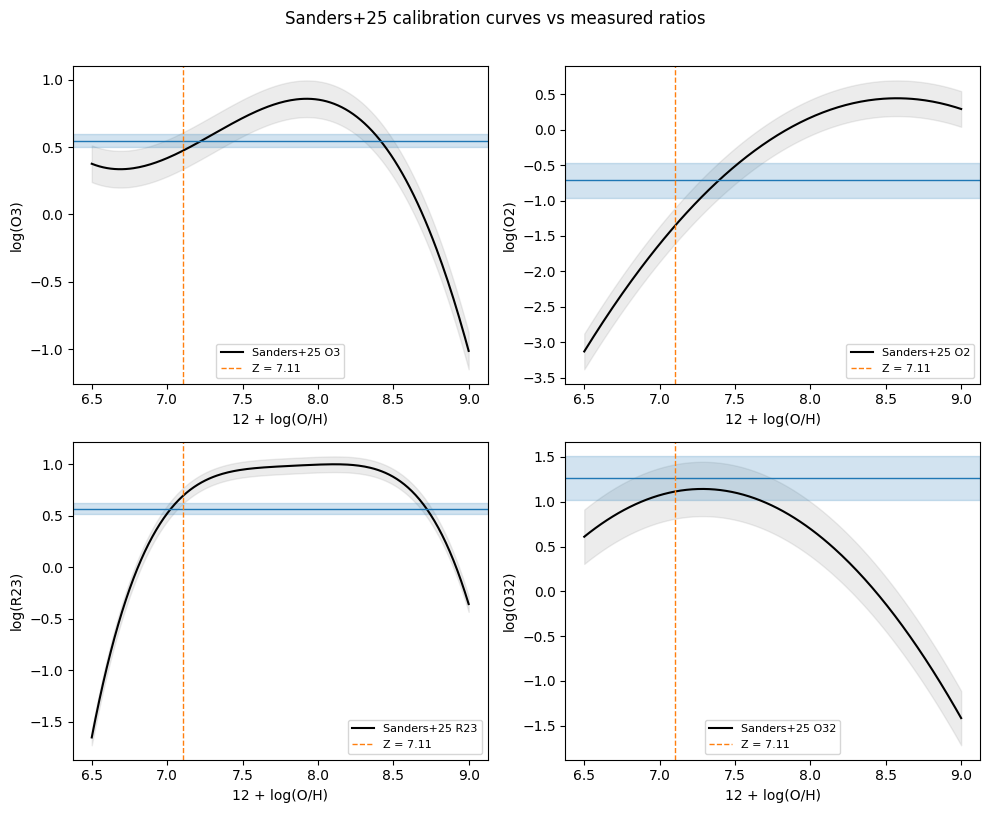

In [23]:
# Plot Sanders+25 calibration curves vs the measured ratios
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
z_grid = np.linspace(6.5, 9.0, 200)

for ax, (diag_name, cal) in zip(axes.ravel(), CALIBRATIONS.items()):
    # Calibration curve
    y_model = [sum(c * (z - Z_REF) ** i for i, c in enumerate(cal["coeffs"])) for z in z_grid]
    ax.plot(z_grid, y_model, "k-", lw=1.5, label=f"Sanders+25 {diag_name}")
    ax.fill_between(
        z_grid,
        np.array(y_model) - cal["sigma_cal"],
        np.array(y_model) + cal["sigma_cal"],
        alpha=0.15, color="0.5",
    )

    # Measured ratio
    if diag_name in ratios:
        ax.axhline(ratios[diag_name]["val"], color="C0", ls="-", lw=1)
        ax.axhspan(
            ratios[diag_name]["val"] - ratios[diag_name]["err"],
            ratios[diag_name]["val"] + ratios[diag_name]["err"],
            alpha=0.2, color="C0",
        )

    # Best-fit metallicity
    ax.axvline(abund_strong.OH, color="C1", ls="--", lw=1, label=f"Z = {abund_strong.OH:.2f}")

    ax.set_xlabel("12 + log(O/H)")
    ax.set_ylabel(f"log({diag_name})")
    ax.legend(fontsize=8)

plt.suptitle("Sanders+25 calibration curves vs measured ratios", y=1.01)
plt.tight_layout()

## 12. Summary table for paper comparison

Compile all key measurements into a single summary table.

In [24]:
print("=" * 60)
print("ABUNDANCE SUMMARY: EXCELS 63107 (z = 8.271)")
print("=" * 60)
print()
print("--- Direct T_e method (Salim+18 dust, DESI T_e-T_e) ---")
print(f"  A_V            = {abund_direct.Av:.3f}")
print(f"  T_e(O++)       = {abund_direct.Te_high:.0f} K")
print(f"  T_e(O+)        = {abund_direct.Te_low:.0f} K")
print(f"  n_e            = {abund_direct.ne:.0f} cm^-3")
if isinstance(abund_direct.OH_err, tuple):
    print(f"  12+log(O/H)    = {abund_direct.OH:.3f} (-{abund_direct.OH_err[0]:.3f}, +{abund_direct.OH_err[1]:.3f})")
else:
    print(f"  12+log(O/H)    = {abund_direct.OH:.3f} +/- {abund_direct.OH_err:.3f}")
if abund_direct.NO is not None:
    if isinstance(abund_direct.NO_err, tuple):
        print(f"  log(N/O)       = {abund_direct.NO:.3f} (-{abund_direct.NO_err[0]:.3f}, +{abund_direct.NO_err[1]:.3f})")
    else:
        print(f"  log(N/O)       = {abund_direct.NO:.3f} +/- {abund_direct.NO_err}")
if abund_direct.ionic:
    for ion, val in abund_direct.ionic.items():
        print(f"  {ion:<14s}  = {val:.3e}")

print()
print("--- Forward model (Cullen+25 approach, Aller 1984 Hb) ---")
print(f"  A_V            = {abund_forward.Av:.3f}")
print(f"  T_e            = {abund_forward.Te_high:.0f} K  (-{fwd['Te_err'][0]:.0f}, +{fwd['Te_err'][1]:.0f})")
print(f"  n_e            = {abund_forward.ne:.0f} cm^-3  (-{fwd['ne_err'][0]:.0f}, +{fwd['ne_err'][1]:.0f})")
if isinstance(abund_forward.OH_err, tuple):
    print(f"  12+log(O/H)    = {abund_forward.OH:.3f} (-{abund_forward.OH_err[0]:.3f}, +{abund_forward.OH_err[1]:.3f})")
else:
    print(f"  12+log(O/H)    = {abund_forward.OH:.3f} +/- {abund_forward.OH_err:.3f}")
if abund_forward.ionic:
    for param, val in abund_forward.ionic.items():
        print(f"  {param:<14s}  = {val:.3f}")

print()
print("--- Strong-line method (Sanders+25) ---")
print(f"  12+log(O/H)    = {abund_strong.OH:.3f} (-{abund_strong.OH_err[0]:.3f}, +{abund_strong.OH_err[1]:.3f})")
print(f"  Ratios used    = {abund_strong.ratios_used}")
#print(f"  chi2           = {abund_strong.chi2:.2f}")
print()
print("--- Comparison ---")
print(f"  Direct         = {abund_direct.OH:.3f}")
print(f"  Forward        = {abund_forward.OH:.3f}")
print(f"  Strong-line    = {abund_strong.OH:.3f}")
diff_df = abund_direct.OH - abund_forward.OH
diff_ds = abund_direct.OH - abund_strong.OH
print(f"  Direct - Forward    = {diff_df:+.3f} dex")
print(f"  Direct - Strong     = {diff_ds:+.3f} dex")

ABUNDANCE SUMMARY: EXCELS 63107 (z = 8.271)

--- Direct T_e method (Salim+18 dust, DESI T_e-T_e) ---
  A_V            = 0.000
  T_e(O++)       = 52515 K
  T_e(O+)        = 39761 K
  n_e            = 100 cm^-3
  12+log(O/H)    = 6.794 (-0.194, +0.206)
  O++/H+          = 5.368e-06
  O+/H+           = 1.993e-07
  Ne++/H+         = 1.488e-06

--- Forward model (Cullen+25 approach, Aller 1984 Hb) ---
  A_V            = 0.000
  T_e            = 42795 K  (-14947, +23225)
  n_e            = 325 cm^-3  (-319, +22005)
  12+log(O/H)    = 6.831 (-0.189, +0.246)
  log_Opp         = -5.189
  log_Op          = -6.680
  log_Nepp        = -5.754

--- Strong-line method (Sanders+25) ---
  12+log(O/H)    = 7.105 (-0.073, +0.095)
  Ratios used    = ['O3', 'O2', 'R23', 'O32']

--- Comparison ---
  Direct         = 6.794
  Forward        = 6.831
  Strong-line    = 7.105
  Direct - Forward    = -0.038 dex
  Direct - Strong     = -0.312 dex
